<a href="https://colab.research.google.com/github/rahulsinghshah/assessment/blob/main/ml_regression_assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("/content/train-test.csv",
                 low_memory=False,
                 parse_dates=["date"])

In [9]:
df.head(10)

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28
5,TR-000006,Phoenix,Corpus Christi,28.75668,-115.87725,28.61374,-95.89569,1396.4,Flatbed,17018.0,2025-01-01,0.95167,1.92983,2676.98
6,TR-000007,Fresno,San Antonio,33.07921,-119.79528,29.50969,-98.40059,1502.6,Dry Van,19112.0,2025-01-01,0.95696,1.82074,2718.54
7,TR-000008,San Francisco,Kansas City,35.19670,-121.69849,39.41104,-91.12450,1976.9,Dry Van,29169.0,2025-01-01,0.97818,1.78430,3522.92
8,TR-000009,Bakersfield,Montgomery,33.28832,-116.67935,31.37602,-86.10743,2027.7,Dry Van,35018.0,2025-01-01,0.96534,1.79522,3675.27
9,TR-000010,Albuquerque,Phoenix,35.39918,-109.59792,28.75668,-115.87725,717.1,Flatbed,34671.0,2025-01-01,0.98475,2.17079,1578.83


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [7]:
df.isna().sum()

,0
load_id,0
pickup,0
delivery,0
pickup_lat,0
pickup_lon,0
delivery_lat,0
delivery_lon,0
distance,0
equipment,0
weight,300


In [11]:
df.date.dtypes

dtype('<M8[ns]')

In [12]:
df.date[:1000]

,date
0,2025-01-01
1,2025-01-01
2,2025-01-01
3,2025-01-01
4,2025-01-01
...,...
995,2025-01-07
996,2025-01-07
997,2025-01-07
998,2025-01-07


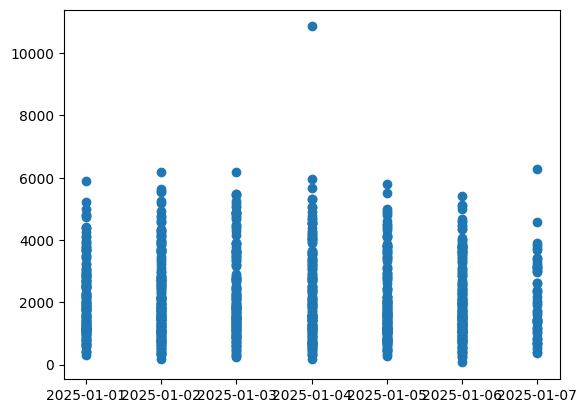

In [13]:
fig, ax = plt.subplots()
ax.scatter(df["date"][:1000], df["posted_rate"][:1000])

**Sort DataFrame by saledate**

when working with time series, it's good idea to sort it by date.

In [16]:
# sort dataframe in date order
df.sort_values(by=["date"], inplace=True, ascending=True)
df.date.head(10)

,date
0,2025-01-01
1,2025-01-01
2,2025-01-01
3,2025-01-01
4,2025-01-01
5,2025-01-01
6,2025-01-01
72,2025-01-01
7,2025-01-01
9,2025-01-01


**Make a copy of the DataFrame**

we make a copy of the dataframe so when we manipulate the copy, we've still got the original data.

In [17]:
# make a copy
df_temp = df.copy()

add datetime paremeter for `date` column

In [19]:
df_temp[:1].date.dt.year

,date
0,2025


In [21]:
df_temp[:1].date.dt.day

,date
0,1


In [22]:
df_temp[:1].date

,date
0,2025-01-01


In [23]:
df_temp["Year"] = df_temp.date.dt.year
df_temp["Month"] = df_temp.date.dt.month
df_temp["Day"] = df_temp.date.dt.day
df_temp["DayOfWeek"] = df_temp.date.dt.dayofweek
df_temp["DayOfYear"] = df_temp.date.dt.dayofyear

In [24]:
df_temp.head().T

,0,1,2,3,4
load_id,TR-000001,TR-000002,TR-000003,TR-000004,TR-000005
pickup,Richmond,Richmond,Philadelphia,Hartford,Dallas
delivery,Baltimore,Philadelphia,Green Bay,Atlanta,Nashville
pickup_lat,38.09122,38.09122,39.22317,39.55328,31.83025
pickup_lon,-76.78906,-76.78906,-72.9671,-72.18051,-94.38343
delivery_lat,38.16908,39.22317,44.30296,34.84933,35.29479
delivery_lon,-72.74564,-72.9671,-87.52871,-86.2894,-88.08915
distance,274.3,280.5,967.8,965.4,541.9
equipment,Dry Van,Reefer,Dry Van,Dry Van,Reefer
weight,30658.0,17555.0,31721.0,32333.0,35183.0


In [25]:
# Now we've enriched our dataframe with date and time features, we can remove `date`
df_temp.drop("date", axis=1, inplace=True)

In [26]:
df_temp.pickup.value_counts()

,count
pickup,
Oklahoma City,1242
Lexington,1209
Bakersfield,1193
Fort Wayne,1170
Hartford,1150
...,...
Detroit,337
Washington,337
St. Louis,318


In [27]:
df_temp.delivery.value_counts()

,count
delivery,
Lexington,1197
Fort Wayne,1176
Baton Rouge,1167
Bakersfield,1156
Hartford,1143
...,...
St. Louis,344
Birmingham,318
Detroit,307


In [28]:
len(df_temp)

48000

#Convert string to categories
One way we can turn all of our data into numbers is by converting them into pandas catgories.

In [29]:
pd.api.types.is_object_dtype(df_temp["pickup"])

True

In [30]:
df_temp["pickup"].dtypes

dtype('O')

In [31]:
for label, content in df_temp.items():
  if pd.api.types.is_object_dtype(content) or pd.api.types.is_string_dtype(content):
    df_temp[label] = content.astype("category").cat.as_ordered()

In [32]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48000 entries, 0 to 47999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   load_id       48000 non-null  category
 1   pickup        48000 non-null  category
 2   delivery      48000 non-null  category
 3   pickup_lat    48000 non-null  float64 
 4   pickup_lon    48000 non-null  float64 
 5   delivery_lat  48000 non-null  float64 
 6   delivery_lon  48000 non-null  float64 
 7   distance      48000 non-null  float64 
 8   equipment     48000 non-null  category
 9   weight        47700 non-null  float64 
 10  market_index  47626 non-null  float64 
 11  quote_signal  48000 non-null  float64 
 12  posted_rate   48000 non-null  float64 
 13  Year          48000 non-null  int32   
 14  Month         48000 non-null  int32   
 15  Day           48000 non-null  int32   
 16  DayOfWeek     48000 non-null  int32   
 17  DayOfYear     48000 non-null  int32   
dtypes: category

In [33]:
df_temp.pickup.cat.categories

Index(['Albany', 'Albuquerque', 'Amarillo', 'Atlanta', 'Austin', 'Bakersfield',
       'Baltimore', 'Baton Rouge', 'Birmingham', 'Boston', 'Buffalo',
       'Charleston', 'Chattanooga', 'Cincinnati', 'Columbia', 'Corpus Christi',
       'Dallas', 'Dayton', 'Detroit', 'El Paso', 'Fort Wayne', 'Fresno',
       'Grand Rapids', 'Green Bay', 'Greensboro', 'Harrisburg', 'Hartford',
       'Houston', 'Indianapolis', 'Jacksonville', 'Kansas City', 'Las Vegas',
       'Lexington', 'Little Rock', 'Los Angeles', 'Louisville', 'Lubbock',
       'Madison', 'Memphis', 'Milwaukee', 'Mobile', 'Montgomery', 'Nashville',
       'New Orleans', 'New York', 'Oklahoma City', 'Philadelphia', 'Phoenix',
       'Providence', 'Raleigh', 'Reno', 'Richmond', 'Salt Lake City',
       'San Antonio', 'San Francisco', 'Savannah', 'Shreveport', 'St. Louis',
       'Syracuse', 'Tampa', 'Toledo', 'Tucson', 'Tulsa', 'Washington'],
      dtype='object')

In [34]:
df_temp.pickup.cat.codes

,0
0,51
1,51
2,46
3,26
4,16
...,...
47996,24
47912,35
47989,17
47911,26


With the Pandas Categories we have a way to access all of our data in the form of numbers

In [35]:
# Missing data
df_temp.isna().sum()/len(df_temp)

,0
load_id,0.000000
pickup,0.000000
delivery,0.000000
pickup_lat,0.000000
pickup_lon,0.000000
delivery_lat,0.000000
delivery_lon,0.000000
distance,0.000000
equipment,0.000000
weight,0.006250


#Fill missing values

In [36]:
for label, content in df_temp.items():
  if pd.api.types.is_numeric_dtype(content):
    print(label)

pickup_lat
pickup_lon
delivery_lat
delivery_lon
distance
weight
market_index
quote_signal
posted_rate
Year
Month
Day
DayOfWeek
DayOfYear


In [37]:
# check which numeric column contain null values
for label, content in df_temp.items():
  if pd.api.types.is_numeric_dtype(content):
    if pd.isnull(content).sum():
      print(label)

weight
market_index


In [38]:
# fill rows with the median
for label, content in df_temp.items():
  if pd.api.types.is_numeric_dtype(content):
    if pd.isnull(content).sum():
      #add binary column which tells us if data was missing or not
      df_temp[label+"_is_missing"] = pd.isnull(content)
      #fill with median
      df_temp[label] = content.fillna(content.median())

In [40]:
# check to see how many examples were missing
df_temp.weight_is_missing.value_counts()

,count
weight_is_missing,
False,47700
True,300


In [41]:
df_temp.isna().sum()

,0
load_id,0
pickup,0
delivery,0
pickup_lat,0
pickup_lon,0
delivery_lat,0
delivery_lon,0
distance,0
equipment,0
weight,0


In [42]:
# turn categorical values into numbers
for label, content in df_temp.items():
  if not pd.api.types.is_numeric_dtype(content):
    # turn categories into numbers and add +1
    df_temp[label] = pd.Categorical(content).codes+1

+1: This adds 1 to all the numerical codes. This is often done because the .codes attribute assigns -1 to missing values (NaN). altho we have no missing values but its necessary.

In [43]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48000 entries, 0 to 47999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   load_id                  48000 non-null  int32  
 1   pickup                   48000 non-null  int8   
 2   delivery                 48000 non-null  int8   
 3   pickup_lat               48000 non-null  float64
 4   pickup_lon               48000 non-null  float64
 5   delivery_lat             48000 non-null  float64
 6   delivery_lon             48000 non-null  float64
 7   distance                 48000 non-null  float64
 8   equipment                48000 non-null  int8   
 9   weight                   48000 non-null  float64
 10  market_index             48000 non-null  float64
 11  quote_signal             48000 non-null  float64
 12  posted_rate              48000 non-null  float64
 13  Year                     48000 non-null  int32  
 14  Month                    48

In [44]:
df_temp.head().T

,0,1,2,3,4
load_id,1,2,3,4,5
pickup,52,52,47,27,17
delivery,7,47,24,4,43
pickup_lat,38.09122,38.09122,39.22317,39.55328,31.83025
pickup_lon,-76.78906,-76.78906,-72.9671,-72.18051,-94.38343
delivery_lat,38.16908,39.22317,44.30296,34.84933,35.29479
delivery_lon,-72.74564,-72.9671,-87.52871,-86.2894,-88.08915
distance,274.3,280.5,967.8,965.4,541.9
equipment,1,3,1,1,3
weight,30658.0,17555.0,31721.0,32333.0,35183.0


so now all of our data is numeric and we don't have any missing value either, now we are able to build a ML model.

In [52]:
df_temp.Month

,Month
0,1
1,1
2,1
3,1
4,1
...,...
47996,10
47912,10
47989,10
47911,10


#Splitting the data

In [51]:
from sklearn.model_selection import train_test_split

In [54]:
#Split data into train and test set based on Month
df_test = df_temp[df_temp['Month'].isin([9,10])]
df_train = df_temp[~df_temp['Month'].isin([9,10])]

len(df_test), len(df_train)

(9523, 38477)

In [56]:
# Split into X & y
X_train, y_train = df_train.drop(['posted_rate', 'load_id'], axis=1), df_train.posted_rate
X_test, y_test = df_test.drop(['posted_rate', 'load_id'], axis=1), df_test.posted_rate

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((38477, 18), (38477,), (9523, 18), (9523,))

#Evaluation function

In [72]:
#create an evaluation function
from sklearn.metrics import mean_squared_log_error, mean_absolute_error, r2_score

def rmsle(y_test, y_preds):
  '''
  calculates root mean squared log error between predicted and true label
  '''
  return np.sqrt(mean_squared_log_error(y_test, y_preds))

#create function to evaluate model on a few different levels
def show_scores(model):
  train_preds = model.predict(X_train)
  val_preds = model.predict(X_test)

  # Ensure predictions are non-negative for RMSLE
  train_preds[train_preds < 0] = 0
  val_preds[val_preds < 0] = 0

  scores = {"Train MAE": mean_absolute_error(y_train, train_preds),
            "Val MAE": mean_absolute_error(y_test, val_preds),
            "Train rmsle": rmsle(y_train, train_preds),
            "Val rmsle": rmsle(y_test, val_preds),
            "Train r2": r2_score(y_train, train_preds),
            "Val r2": r2_score(y_test, val_preds)}
  return scores

#Building ML model

In [75]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Put Models in a dictionary
models = {"LR": LinearRegression(),
          "Ridge": Ridge(),
          "RF": RandomForestRegressor(),
          "GB": GradientBoostingRegressor() }

# Create a function to fit and score models
def fit_and_score(models, X_train, X_test, y_train, y_test):
  '''
  Fits and evaluates the given ML model
  models: dict of different Scikit-learn models
  '''
  # Set random seed
  np.random.seed(42)

  # Dict to keep model score
  model_score = {}

  # Loop through models
  for name, model in models.items():
    #Fit the model
    model.fit(X_train, y_train)
    #Evaluate the model and append its score to model_score
    model_score[name] = show_scores(model)
  return model_score

In [77]:
model_score = fit_and_score(models=models,
                            X_train=X_train,
                            X_test=X_test,
                            y_train=y_train,
                            y_test=y_test)
pd.DataFrame(model_score)

,LR,Ridge,RF,GB
Train MAE,139.651564,139.649747,49.559826,104.331269
Val MAE,143.590276,143.528241,206.268047,114.562861
Train rmsle,0.185409,0.185400,0.070959,0.152578
Val rmsle,0.183334,0.183355,0.186276,0.164627
Train r2,0.839834,0.839834,0.976415,0.861020
Val r2,0.824456,0.824472,0.792050,0.827356


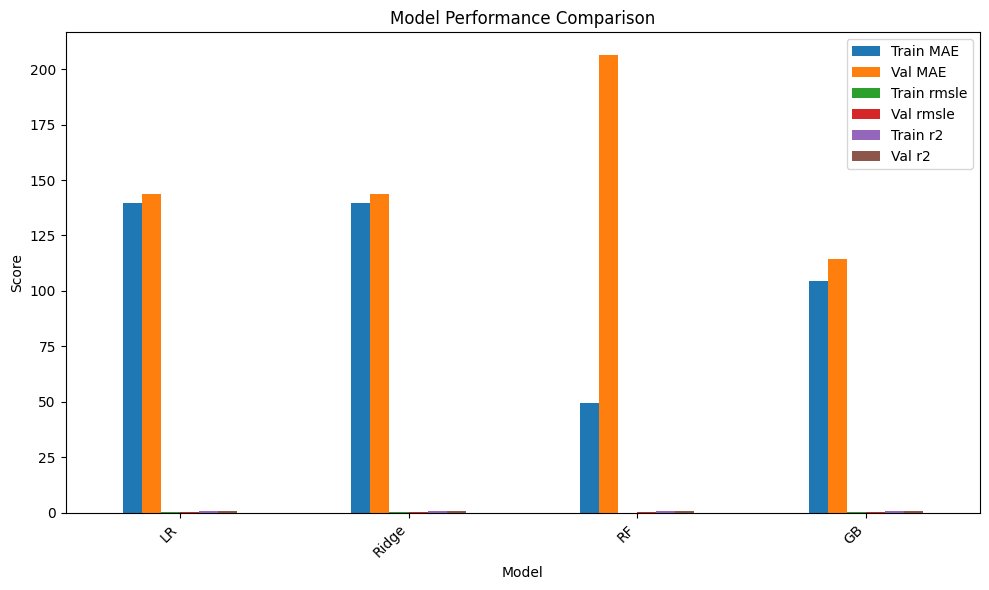

In [78]:
model_comparison = pd.DataFrame(model_score)
model_comparison.T.plot(kind="bar", figsize=(10, 6))
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Hyperparameter Tuning with RandomizedSearchCV for RandomForestRegressor

In [79]:
# Hyperparameter tuning with RandomizedSearchCV
%%time
from sklearn.model_selection import RandomizedSearchCV

rf_grid = {"n_estimators": np.arange(10, 100, 10),
           "max_depth": [None, 3, 5, 10],
           "min_samples_split": np.arange(2, 20, 2),
           "min_samples_leaf": np.arange(1, 20, 2),
           "max_features": [0.5, 1.0, "sqrt", "log2"]}

rs_model = RandomizedSearchCV(RandomForestRegressor(n_jobs=-1, random_state=42),
                              param_distributions=rf_grid,
                              n_iter=20, # Increased iterations for better results
                              cv=5,
                              verbose=True,
                              random_state=42)
rs_model.fit(X_train, y_train)

print("RandomForestRegressor Best Parameters:", rs_model.best_params_)
print("RandomForestRegressor Best CV Score:", rs_model.best_score_)

# Evaluate the best Random Forest model
best_rf_model = rs_model.best_estimator_
rf_tuned_scores = show_scores(best_rf_model)
print("RandomForestRegressor Tuned Model Scores:", rf_tuned_scores)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
RandomForestRegressor Best Parameters: {'n_estimators': np.int64(80), 'min_samples_split': np.int64(14), 'min_samples_leaf': np.int64(11), 'max_features': 0.5, 'max_depth': None}
RandomForestRegressor Best CV Score: 0.8410479429600424
RandomForestRegressor Tuned Model Scores: {'Train MAE': 94.04061599602714, 'Val MAE': 122.39419235883943, 'Train rmsle': np.float64(0.1375591653384616), 'Val rmsle': np.float64(0.1644270569286645), 'Train r2': 0.8705293841633284, 'Val r2': 0.8275966437972189}
CPU times: user 16min 4s, sys: 2.82 s, total: 16min 7s
Wall time: 9min 47s


In [80]:
show_scores(rs_model)

{'Train MAE': 94.04061599602714,
 'Val MAE': 122.39419235883943,
 'Train rmsle': np.float64(0.1375591653384616),
 'Val rmsle': np.float64(0.1644270569286645),
 'Train r2': 0.8705293841633284,
 'Val r2': 0.8275966437972189}

### Hyperparameter Tuning with RandomizedSearchCV for GradientBoostingRegressor

In [81]:
%%time

# Define the parameter grid for GradientBoostingRegressor
gb_grid = {
    'n_estimators': np.arange(100, 500, 100),
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': np.arange(2, 10, 2),
    'min_samples_leaf': np.arange(1, 10, 2),
    'max_features': ['sqrt', 'log2', None]
}

rs_gb_model = RandomizedSearchCV(GradientBoostingRegressor(random_state=42),
                                 param_distributions=gb_grid,
                                 n_iter=20, # Number of parameter settings that are sampled
                                 cv=5,
                                 verbose=True,
                                 random_state=42,
                                 n_jobs=-1)

rs_gb_model.fit(X_train, y_train)

print("GradientBoostingRegressor Best Parameters:", rs_gb_model.best_params_)
print("GradientBoostingRegressor Best CV Score:", rs_gb_model.best_score_)

# Evaluate the best Gradient Boosting model
best_gb_model = rs_gb_model.best_estimator_
gb_tuned_scores = show_scores(best_gb_model)
print("GradientBoostingRegressor Tuned Model Scores:", gb_tuned_scores)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
GradientBoostingRegressor Best Parameters: {'n_estimators': np.int64(100), 'min_samples_split': np.int64(4), 'min_samples_leaf': np.int64(7), 'max_features': None, 'max_depth': 3, 'learning_rate': 0.2}
GradientBoostingRegressor Best CV Score: 0.8415445355465838
GradientBoostingRegressor Tuned Model Scores: {'Train MAE': 108.68355573821614, 'Val MAE': 129.17364032202823, 'Train rmsle': np.float64(0.1519090599870319), 'Val rmsle': np.float64(0.16842857922504853), 'Train r2': 0.8572868359901922, 'Val r2': 0.8251272671302676}
CPU times: user 23.5 s, sys: 1.51 s, total: 25.1 s
Wall time: 27min 35s


In [82]:
show_scores(rs_gb_model)

{'Train MAE': 108.68355573821614,
 'Val MAE': 129.17364032202823,
 'Train rmsle': np.float64(0.1519090599870319),
 'Val rmsle': np.float64(0.16842857922504853),
 'Train r2': 0.8572868359901922,
 'Val r2': 0.8251272671302676}

In [89]:
import joblib

# Save the best Random Forest model
joblib.dump(rs_model.best_estimator_, "best_random_forest_model.joblib")
print("RandomForestRegressor model saved as 'best_random_forest_model.joblib'")

RandomForestRegressor model saved as 'best_random_forest_model.joblib'


#Make Prediction on Validation data

In [88]:
df_val = pd.read_csv("/content/validation.csv",
                      low_memory=False,
                     parse_dates=["date"])
df_val.head(10)

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal
0,TE-000001,Baton Rouge,Mobile,30.50134,-92.65374,31.80442,-88.25195,331.4,Flatbed,19958.0,2025-11-01,0.90402,1.86388
1,TE-000002,Savannah,Los Angeles,33.60973,-82.29994,28.56624,-116.70249,2406.2,Reefer,34114.0,2025-11-01,0.92851,1.86240
2,TE-000003,San Francisco,Raleigh,35.19670,-121.69849,35.37376,-77.47605,2846.6,Dry Van,33435.0,2025-11-01,0.88117,1.95480
3,TE-000004,Dayton,Los Angeles,39.87206,-85.62931,28.56624,-116.70249,2261.6,Dry Van,25392.0,2025-11-01,0.89156,2.14579
4,TE-000005,Memphis,San Antonio,35.56802,-89.52871,29.50969,-98.40059,800.4,Flatbed,NaN,2025-11-01,0.88308,2.22541
5,TE-000006,Columbia,Fresno,34.63570,-83.28506,33.07921,-119.79528,2405.4,Dry Van,26124.0,2025-11-01,0.86615,2.19932
6,TE-000007,Raleigh,Phoenix,35.37376,-77.47605,28.75668,-115.87725,2646.5,Reefer,26069.0,2025-11-01,0.91528,2.24680
7,TE-000008,San Antonio,Detroit,29.50969,-98.40059,43.61923,-84.04517,1448.6,Dry Van,28194.0,2025-11-01,0.93007,2.20590
8,TE-000009,Lexington,Harrisburg,36.99152,-84.99876,39.71695,-78.12481,482.9,Dry Van,39674.0,2025-11-01,0.93645,2.00931
9,TE-000010,Norfolk,Columbia,37.12278,-75.87106,34.63570,-83.28506,534.4,Dry Van,22086.0,2025-11-01,0.88997,1.71182


In [91]:
def preprocess_data(df):
  """
  Performs transformation on DF and returns transformed DF with the same format as training data.
  Assumes 'date' column exists and needs to be processed.
  """

  # Extract date features
  df["Year"] = df.date.dt.year
  df["Month"] = df.date.dt.month
  df["Day"] = df.date.dt.day
  df["DayOfWeek"] = df.date.dt.dayofweek
  df["DayOfYear"] = df.date.dt.dayofyear

  # Remove original 'date' column
  df.drop("date", axis=1, inplace=True)

  # 2. Fill numeric missing values and add is_missing column
  for label, content in df.items():
      if pd.api.types.is_numeric_dtype(content):
          if pd.isnull(content).sum():
              #add binary column which tells us if data was missing or not
              df[label+"_is_missing"] = pd.isnull(content)
              #fill with median
              df[label] = content.fillna(content.median())

  # 3. Convert non-numeric (object/string) columns to numerical codes (+1)
  for label, content in df.items():
      if not pd.api.types.is_numeric_dtype(content):
          # Convert to category first, then to codes (+1)
          df[label] = pd.Categorical(content).codes + 1

  return df

In [92]:
# Step 2: Predict every load in validation.csv

# Create a copy of df_val to avoid modifying the original loaded data
df_val_copy = df_val.copy()

# Preprocess the validation data using the corrected function
df_val_processed = preprocess_data(df_val_copy)

# Store load_id before dropping it from features
val_load_ids = df_val_processed["load_id"]

# Drop load_id from the features DataFrame, as the model was trained without it
df_val_features = df_val_processed.drop("load_id", axis=1)

# Align columns of validation features with the training features (X_train)
# This is crucial to ensure the model receives features in the expected order and set
train_cols = X_train.columns

In [95]:
# Check if we have same features or not
set(train_cols) - set(df_val_features.columns)

set()

In [96]:
# Reorder columns to match the order of X_train
df_val_features = df_val_features[train_cols]

print("Validation features head after preprocessing and alignment:")
display(df_val_features.head())
print("\nValidation features info after preprocessing and alignment:")
df_val_features.info()

Validation features head after preprocessing and alignment:


,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,market_index,quote_signal,Year,Month,Day,DayOfWeek,DayOfYear,weight_is_missing,market_index_is_missing
0,9,47,30.50134,-92.65374,31.80442,-88.25195,331.4,2,19958.0,0.90402,1.86388,2025,11,1,5,305,False,False
1,64,41,33.60973,-82.29994,28.56624,-116.70249,2406.2,3,34114.0,0.92851,1.86240,2025,11,1,5,305,False,False
2,63,57,35.19670,-121.69849,35.37376,-77.47605,2846.6,1,33435.0,0.88117,1.95480,2025,11,1,5,305,False,False
3,21,41,39.87206,-85.62931,28.56624,-116.70249,2261.6,1,25392.0,0.89156,2.14579,2025,11,1,5,305,False,False
4,45,61,35.56802,-89.52871,29.50969,-98.40059,800.4,2,31193.0,0.88308,2.22541,2025,11,1,5,305,True,False



Validation features info after preprocessing and alignment:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   pickup                   12000 non-null  int8   
 1   delivery                 12000 non-null  int8   
 2   pickup_lat               12000 non-null  float64
 3   pickup_lon               12000 non-null  float64
 4   delivery_lat             12000 non-null  float64
 5   delivery_lon             12000 non-null  float64
 6   distance                 12000 non-null  float64
 7   equipment                12000 non-null  int8   
 8   weight                   12000 non-null  float64
 9   market_index             12000 non-null  float64
 10  quote_signal             12000 non-null  float64
 11  Year                     12000 non-null  int32  
 12  Month                    12000 non-null  int32  
 13  Day            

In [97]:
# Make predictions using the best trained model (RandomForestRegressor in this case)
val_preds = rs_model.best_estimator_.predict(df_val_features)

# Ensure predictions are non-negative, as posted_rate cannot be negative
val_preds[val_preds < 0] = 0

print("\nFirst 10 predictions:", val_preds[:10])


First 10 predictions: [ 859.80578537 4795.96926515 5680.04885883 4297.09835918 1847.9485719
 4599.05985268 5186.52704775 2805.38398596 1063.27546531 1189.92253668]


#Fill the Validation-predictions-template

In [98]:
# Step 3: Fill predicted_rate in validation_predictions_template.csv and save it
# view the file
submission_template = pd.read_csv("/content/validation-predictions-template.csv", low_memory=False)

submission_template.head(10)

,load_id,predicted_rate
0,TE-000001,NaN
1,TE-000002,NaN
2,TE-000003,NaN
3,TE-000004,NaN
4,TE-000005,NaN
5,TE-000006,NaN
6,TE-000007,NaN
7,TE-000008,NaN
8,TE-000009,NaN
9,TE-000010,NaN


In [100]:
# Create a DataFrame for predictions with load_id from the original validation data
predictions_to_update = pd.DataFrame({
    "load_id": df_val["load_id"],
    "predicted_rate_val": val_preds
})

# Load the template file
submission_template_df = pd.read_csv("/content/validation-predictions-template.csv", low_memory=False)

# Set 'load_id' as the index for both
submission_template_df = submission_template_df.set_index('load_id')
predictions_to_update = predictions_to_update.set_index('load_id')

# Update the 'predicted_rate' column in the template with the predicted values
submission_template_df['predicted_rate'].update(predictions_to_update['predicted_rate_val'])

# Reset the index to bring 'load_id' back as a regular column
submission_df = submission_template_df.reset_index()

# Display the first few rows of the final submission file
print("\nFinal submission file head:")
display(submission_df.head())

# Save the submission file as validation_predictions.csv
submission_df.to_csv("validation_predictions.csv", index=False)
print("\nSubmission file saved as 'validation_predictions.csv'")


Final submission file head:


/tmp/ipykernel_530/407762487.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  submission_template_df['predicted_rate'].update(predictions_to_update['predicted_rate_val'])


,load_id,predicted_rate
0,TE-000001,859.805785
1,TE-000002,4795.969265
2,TE-000003,5680.048859
3,TE-000004,4297.098359
4,TE-000005,1847.948572



Submission file saved as 'validation_predictions.csv'


In [107]:
dec_df = pd.read_csv("/content/december_chart_inputs.csv")
dec_df

,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,NaN
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,NaN
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,NaN
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,NaN
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,NaN
5,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-06,NaN
6,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-07,NaN
7,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-08,NaN
8,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-09,NaN
9,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-10,NaN


In [108]:
dec_df.isna().sum()

,0
pickup,0
delivery,0
distance,0
equipment,0
weight,0
date,0
predicted_rate,31


In [109]:
# Load the december_chart_inputs.csv file
dec_df = pd.read_csv("/content/december_chart_inputs.csv", parse_dates=["date"])

# Create a copy
dec_df_copy = dec_df.copy()

# Since 'december_chart_inputs.csv' doesn't have a 'load_id' or 'posted_rate', we'll just preprocess features.
dec_df_processed = preprocess_data(dec_df_copy)

# Align columns of December features with the training features (X_train)
train_cols = X_train.columns

# Drop any extra columns in dec_df_processed that are not in X_train
extra_cols_dec = set(dec_df_processed.columns) - set(train_cols)
if 'posted_rate' in extra_cols_dec: # Ensure 'posted_rate' is not dropped if it somehow appeared
    extra_cols_dec.remove('posted_rate')

if extra_cols_dec:
    dec_df_processed.drop(columns=list(extra_cols_dec), inplace=True)

# Check for missing columns in dec_df_processed
missing_cols_dec = set(train_cols) - set(dec_df_processed.columns)
for col in missing_cols_dec:
    dec_df_processed[col] = 0 # Or appropriate default/median from training data

# Reorder columns to match the order of X_train
df_dec_features = dec_df_processed[train_cols]

print("\nDecember features head after preprocessing and alignment:")
display(df_dec_features.head())
print("\nDecember features info after preprocessing and alignment:")
df_dec_features.info()

# Make predictions using the best trained model
dec_preds = rs_model.best_estimator_.predict(df_dec_features)

# Ensure predictions are non-negative
dec_preds[dec_preds < 0] = 0

print("\nFirst 10 December predictions:", dec_preds[:10])

# Fill the 'predicted_rate' column in the original `dec_df`
dec_df["predicted_rate"] = dec_preds

# Display the updated December DataFrame
print("\nDecember chart inputs with predicted rates:")
display(dec_df.head())

# Optionally, save the updated file
dec_df.to_csv("december_chart_inputs_with_predictions.csv", index=False)
print("\nUpdated 'december_chart_inputs.csv' saved as 'december_chart_inputs_with_predictions.csv'")


December features head after preprocessing and alignment:


,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,market_index,quote_signal,Year,Month,Day,DayOfWeek,DayOfYear,weight_is_missing,market_index_is_missing
0,1,1,0,0,0,0,360,1,32000,0,0,2025,12,1,0,335,0,0
1,1,1,0,0,0,0,360,1,32000,0,0,2025,12,2,1,336,0,0
2,1,1,0,0,0,0,360,1,32000,0,0,2025,12,3,2,337,0,0
3,1,1,0,0,0,0,360,1,32000,0,0,2025,12,4,3,338,0,0
4,1,1,0,0,0,0,360,1,32000,0,0,2025,12,5,4,339,0,0



December features info after preprocessing and alignment:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   pickup                   31 non-null     int8 
 1   delivery                 31 non-null     int8 
 2   pickup_lat               31 non-null     int64
 3   pickup_lon               31 non-null     int64
 4   delivery_lat             31 non-null     int64
 5   delivery_lon             31 non-null     int64
 6   distance                 31 non-null     int64
 7   equipment                31 non-null     int8 
 8   weight                   31 non-null     int64
 9   market_index             31 non-null     int64
 10  quote_signal             31 non-null     int64
 11  Year                     31 non-null     int32
 12  Month                    31 non-null     int32
 13  Day                      31 non-null     int32
 14  D

,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,970.636299
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,971.871024
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,971.871024
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,967.109165
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,967.109165



Updated 'december_chart_inputs.csv' saved as 'december_chart_inputs_with_predictions.csv'


In [112]:
!python -m pip install -r requirements.txt
!python score.py --predictions validation_predictions.csv --december-predictions december_chart_inputs_with_predictions.csv

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.
